# Exploratory Analysis: Winchcombe Meteorite Data

## Preparing & Preprocessing py-GC-MS Datasets for ML

The Winchcombe meteorite was discovered near the town of Winchcombe, Gloucestershire, UK between 28 February and 1 March 2021 and was collected within hours after falling. Having been recovered before major degradation or modification from the terrestrial environment, it remains one of the freshest carbonaceous chondrites to ever be scientifically analysed and sampled (King et al., 2022). 

Carbonaceous chondrites are believed to be fragments of primitive and volatile-rich asteroids from the outer Solar System. The presence of carbon- and nitrogen-bearing organic matter, including soluble protein amino acids (King et al., 2022), opens a critical window into the composition of organic compounds in the early Solar System. As the Winchcombe is rich in organics, it is therefore of particular interest as an abiotic sample in this project.

The py-GC-MS data used to create the overarching preprocessing pipeline within this project and the `mlbiosig` Python package was acquired from a Winchcombe meteorite sample on 29 July 2021. It is a non-hydrolysed sample, meaning it undergoes limited chemical modification before being analysed in order to ensure the molecular composition is largely unchanged and maintain consistency across lab-generated datasets.

**Reproducibility Statement:** All results, numerical values, figures, and plots in this notebook are fully reproducible using the provided code and available data within the the root repository.

In [1]:
# Imports:
import pandas as pd
import matplotlib.pyplot as plt
import math

##### Importing CSV File Data:

In [2]:
df = pd.read_csv("../data/exploratory/winchcombe-nonhyd-sp.CSV")
df.head()

,,"#""+ Scan (rt: 6.097 min) 20210729_1_WICHCOMBE-NONHYD-SP.D """
#Point,X(Thompsons),Y(Counts)
0,50.1,364
1,51.1,433
2,52.0,263
3,53.1,942


As this mass spectra `.csv` file was directly exported from the Agilent MassHunter Qualitative Analysis tool, it would be far more effective to correct the header algorithmically rather than manually fixing each file. Hence, following `read_csv` documentation (pandas development team 2026), I will check if the header line of the exported `.csv` files is incorrect (by flagging for any `#`), ignoring that line, and then replacing the columns names with `point`, `masstocharge`, and `counts`.

In [3]:
# Correcting CSV header line:

expected_cols = ["point", "masstocharge", "counts"]
df = pd.read_csv(
    "../data/exploratory/winchcombe-nonhyd-sp.CSV",  # file path
    comment="#",  # ignore lines beginning with '#'
    names=expected_cols,
)  # replace header names

df.head()

,point,masstocharge,counts
0,0,50.1,364.0
1,1,51.1,433.0
2,2,52.0,263.0
3,3,53.1,942.0
4,4,55.1,2413.0


As the mass spectral file contains the mass spectrum repeated for every scan, each `point` that resets to 0 indicates a new mass spectrum at a different retention time. I will therefore check whether the incorrect headers are handled correctly at the `point` reset in `df`.

In [4]:
# Checking new MS spectrum at point reset:

df.iloc[79:100]

,point,masstocharge,counts
79,79,357.2,240.0
80,80,370.2,163.0
81,81,429.0,322.0
82,82,431.2,189.0
83,0,50.1,364.0
84,1,51.1,433.0
85,2,52.0,263.0
86,3,53.1,942.0
87,4,55.1,2413.0
88,5,56.1,361.0


##### Cleaning Spectral Data:

Prior to creating features from raw spectral data, chemically-motivated checks on the data must be performed, followed by cleaning (if necessary). I begin by first exploring the distribution of intensity values $I(m/z, N)$, where $N$ indicates the scan at a given retention time.

Zero intensities should not be exported by Agilent for a given $m/z$ value, while negative intensities are simply a physical impossibility. $I(m/z, N) < 0$ must therefore be removed from the mass spectral dataset. On the other hand, duplicates of $m/z$ values and their corresponding $I(m/z, N)$ at different points of time are expected, as this is coincidential.

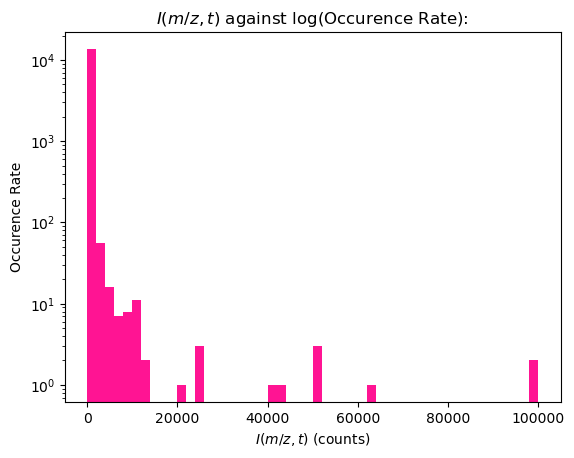

count     13806.000000
mean        124.097487
std        1717.736629
min           0.000052
25%           0.004130
50%           0.250572
75%           6.028277
max      100016.000000
Name: counts, dtype: float64


In [ ]:
# Plotting distribution of intensities across spectral data:

plt.title(rf"$I(m/z, N)$ against log(Occurence Rate):")
plt.hist(df["counts"], bins=50, color="deeppink")
plt.xlabel(rf"$I(m/z, t)$ (counts)")
plt.ylabel("Occurence Rate")
plt.yscale("log")
plt.show()

# Describe mass spectral data:
print(df["counts"].describe())

As shown above by `.describe()` (pandas development team 2026), there is a massive spread in intensities across $m/z$ suggesting a strong right-skewness dominated by a handful of incredibly high-intensity peaks. This is expected in mass spectral data, as the high-intensity peaks are indicative of a base peak (the most abundant fragment ion in this Winchcombe sample).

To further investigate whether the highest intensity peak is in fact the base peak with neighbouring peaks, I will now probe how gradually the intensities increase using `.nlargest()` (pandas development team 2026). This will also check whether there is a large gap between smaller and larger intensity peaks across $m/z$, which could be indicative of an artefact.

In [6]:
# Qualitatively check 10 highest intensity peaks:
print("Number of Intensity values:", len(df))
print("\n5 Highest Intensity Peaks:")
print(df.nlargest(5, "counts"), "\n")

# Quantitatively check how many peaks are above a certain threshold:
print("Percentage of Values above Thresholds:")
for threshold in [1_000, 10_000, 100_000]:
    n = (df["counts"] > threshold).sum()
    print(f"Values above {threshold}: {n} ({n/len(df)*100:.2f}%)")

Number of Intensity values: 13806

5 Highest Intensity Peaks:
      point  masstocharge        counts
460      16          69.1  100016.00000
6952     40          69.1   98091.71875
271     105         202.1   62096.00000
566      16          69.1   51472.00000
967     106         202.1   50752.00000 

Percentage of Values above Thresholds:
Values above 1000: 190 (1.38%)
Values above 10000: 25 (0.18%)
Values above 100000: 1 (0.01%)


Here, the highest intensity peak is most likely the base peak. This conclusion is strengthened by the fact that the highest intensities emerge repeatedly across $m/z \in [69.1, 202.1]$, where $m/z \; 69.1$ appears to be the dominant peak. In a geochemical context, this indicates that there are two chemically-related compounds that elute at different `point` indices and therefore different $t$, which is very plausible.

From the above investigation, it is clear that the minimum intensity in this Winchcombe sample is $\sim  0.000052$. For completeness however, $I(m/z, t) \leq 0$ will still be clipped.

In [7]:
df["counts"] = df["counts"].clip(lower=0)
df = df[df["counts"] > 0]

##### Creating py-MS Vectors:

As the `point` resets are handled correctly and the mass spectral data appears to be chemically genuine, I will now explore what each individual mass spectrum looks like. This will involve collecting $m/z$ and corresponding intensity counts for each mass spectrum indicated by the reset.

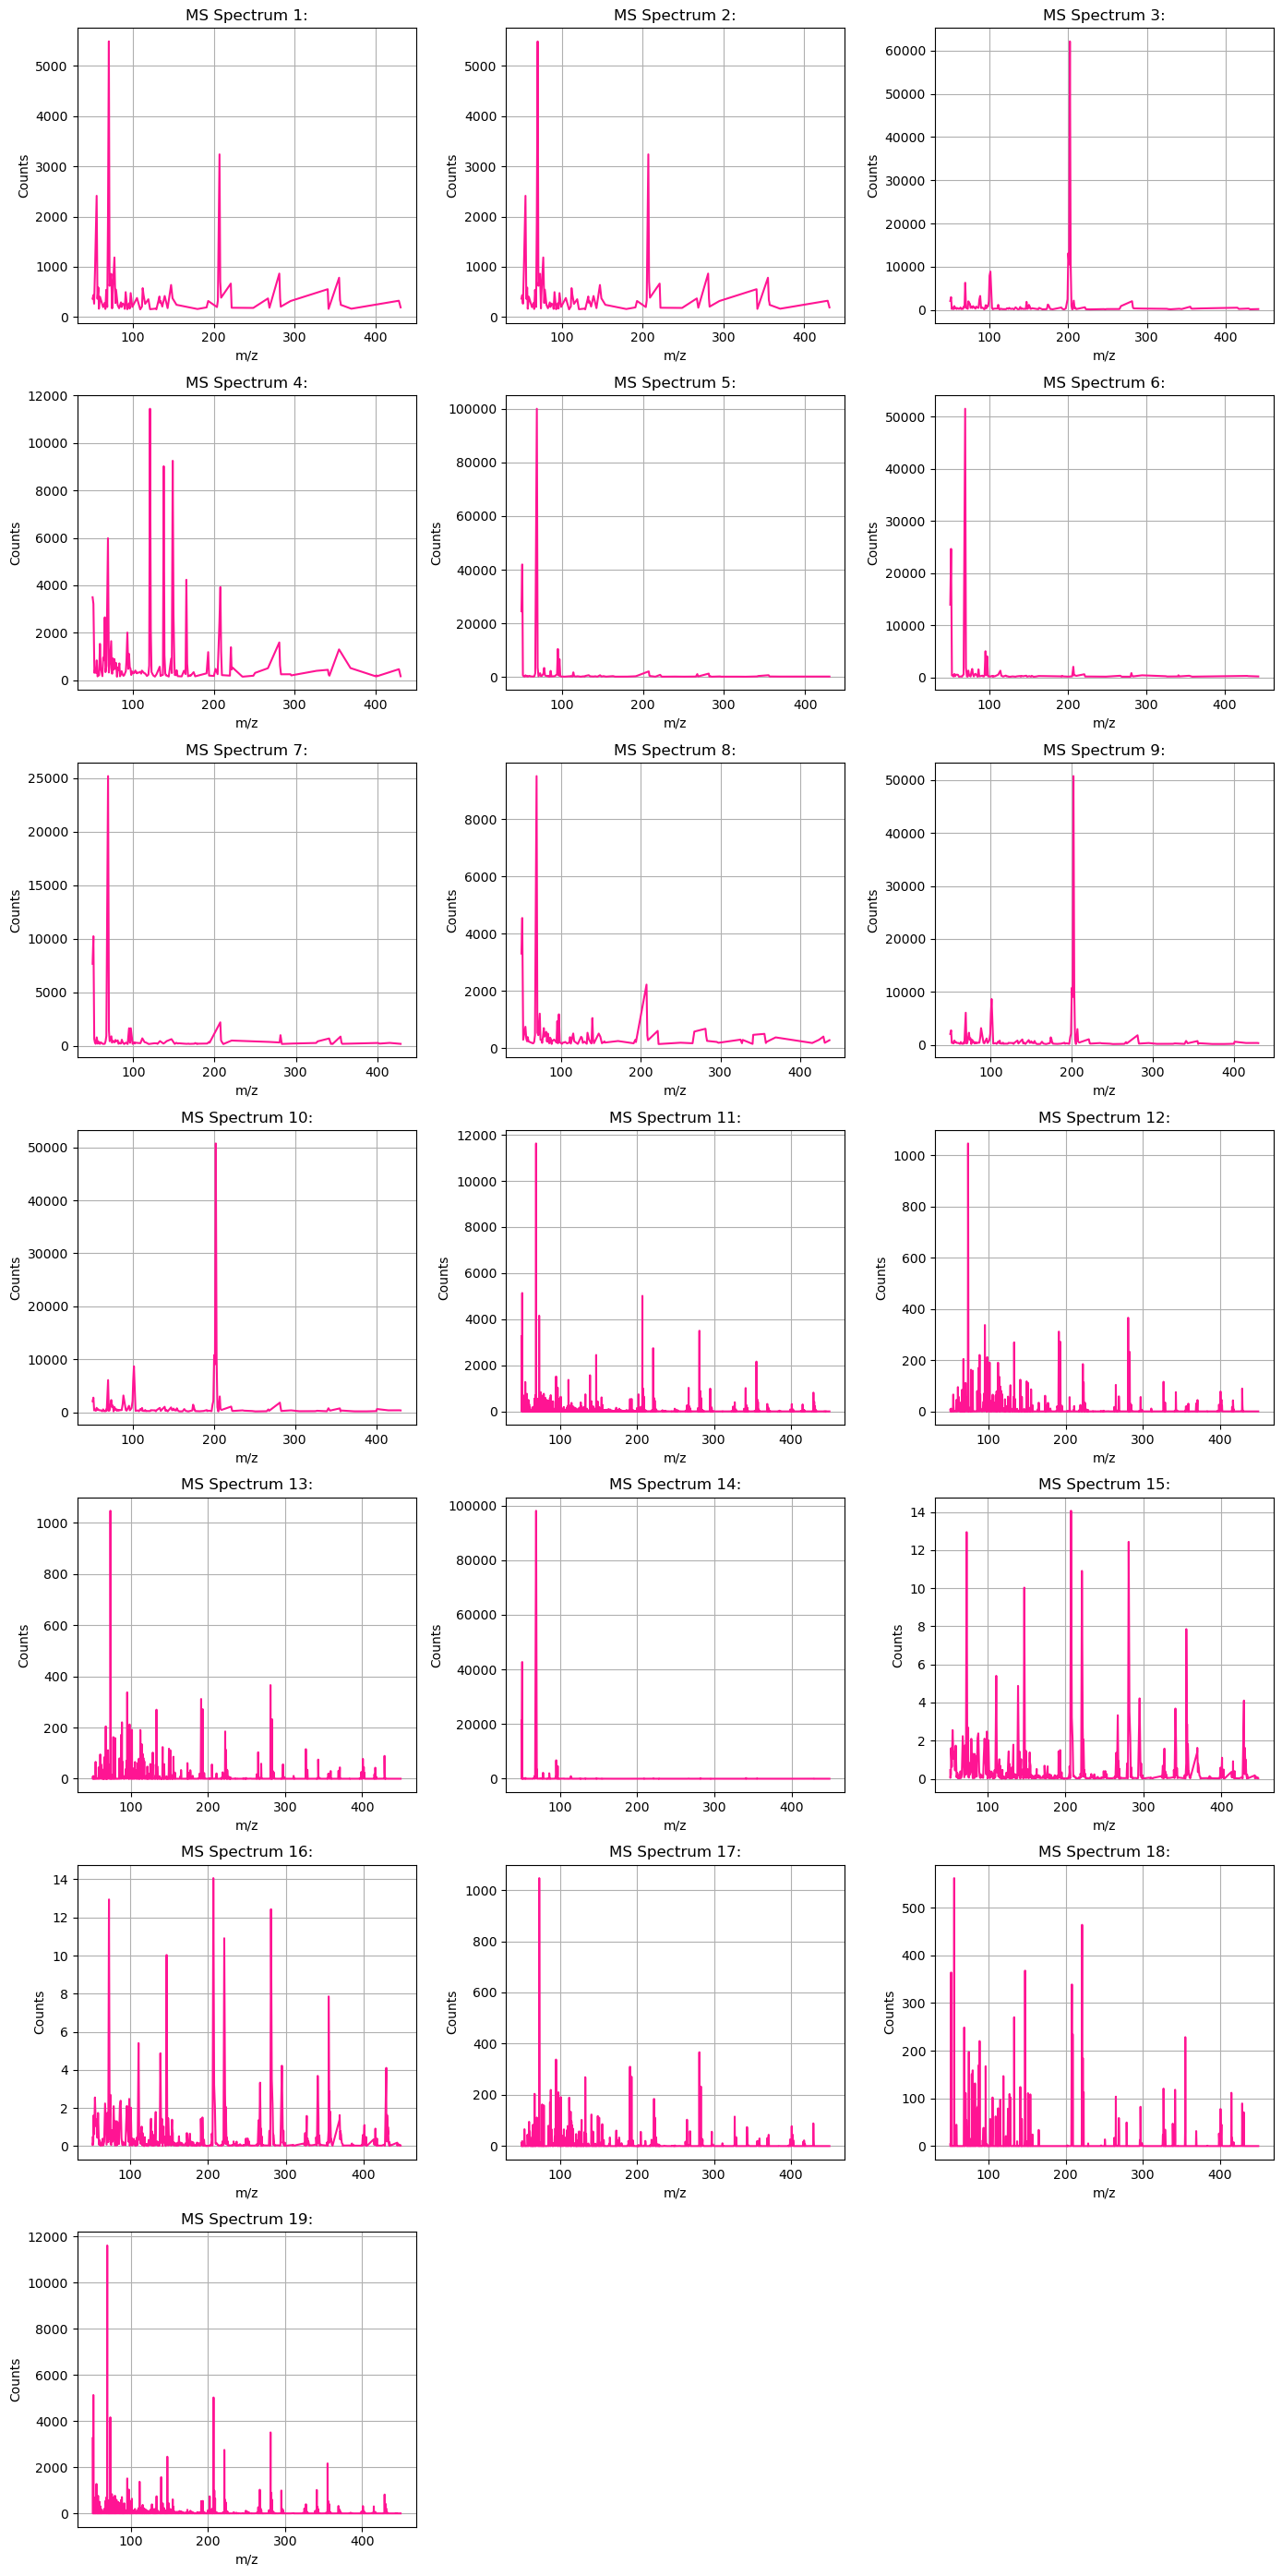

In [8]:
# Collecting individual MS spectrums:

m_z = []  # mass-to-charge ratio (m/z)
counts = []  # intensity counts
spectra = []  # (m/z, counts)
for i in range(len(df)):
    m_z.append(df.masstocharge[i])
    counts.append(df.counts[i])
    if i == len(df) - 1 or df.point.iloc[i + 1] == 0:  # check for reset/end of CSV
        spectra.append((m_z.copy(), counts.copy()))
        m_z, counts = [], []

# Plotting MS Spectrums:

n_cols = 3
n_rows = math.ceil(len(spectra) / n_cols)  # rounding to n_cols plots per row
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))

for i, (m_z, counts) in enumerate(spectra):
    row = i // n_cols  # floor division for row
    cols = i % n_cols  # remainder as column
    axes[row, cols].plot(m_z, counts, color="deeppink")
    axes[row, cols].set_title(f"MS Spectrum {i+1}:")
    axes[row, cols].set_xlabel("m/z")
    axes[row, cols].set_ylabel("Counts")
    axes[row, cols].grid(True)

for i in range(len(spectra), n_rows * n_cols):  # check for unused plots
    row = i // n_cols
    col = i % n_cols
    fig.delaxes(axes[row, col])  # remove subplot

plt.tight_layout()
plt.show()

At the moment, the `point` variable serves as a crucial index for indicating when a mass spectrum begins and ends, where each mass spectrum captures the ($m/z \times$ intensity) in a specific scan $N$. 

For ML, a potential strategy for reducing this information into one vector of data per sample is to sum the intensities across individual $m/z$ values, $I_{\text{sum}}(m/z,N)$, instead of capturing ($m/z \times$ intensity) pairs across multiple mass spectra per sample:

$$I_{\text{sum}}(m/z) = \sum^N I(m/z, N)$$


This allows information about the entire sample to be retained, ultimately creating a pyrolysis-Mass Spectrometry (py-MS) vector.

In [9]:
# Summing intensities across each m/z value:

# summing intensity across all spectra
sum_spectrum = df.groupby("masstocharge")["counts"].sum().reset_index()
sum_spectrum.columns = ["m_z", "intensity"]

# create 1 row per m/z value with summed intensity in vector
winchcombe_vector = sum_spectrum.set_index("m_z")["intensity"]
print(winchcombe_vector.head(10))
print("\nm/z 50.1:", winchcombe_vector[50.1], "summed intensity")

m_z
50.1     87743.632568
50.3         5.203949
50.5         0.108282
50.6         0.157811
50.8         0.272989
51.0       142.107506
51.1    147010.751953
51.2       364.019043
51.3         5.659107
51.7         0.226128
Name: intensity, dtype: float64

m/z 50.1: 87743.63256835938 summed intensity


##### Normalising py-MS Vectors:

As can be seen in the first 10 $m/z$ values, there is a large variation across different $m/z$ and their corresponding summed intensities from the entire sample's individual MS Spectrums. To ensure that these variations do not arise from instrumental effects and that an ML classifier learns to distinguish samples on the relative distribution of peaks rather than total signal magnitude, normalisation will be performed.

In this case, I apply max normalisation, such that every summed intensity, $I_{\text{sum}}$, is divided by the maximum summed intensity, $I_{\text{max}}$, in the sample spectrum:

$$I_{\text{norm}}(m/z) = \frac{I_{\text{sum}}(m/z)}{I_{\text{max}}}$$

This effectively rescales all summed intensities between [0, 1], whereby the most abundant ion fragment ($I_{\text{max}}$) will have $I_{\text{norm}} = 1$.

In [10]:
sum_spectrum["intensity_norm"] = (
    sum_spectrum["intensity"] / sum_spectrum["intensity"].max()
)

# create 1 row per m/z value with normalised summed intensity in vector
winchcombe_vector_norm = sum_spectrum.set_index("m_z")["intensity_norm"]
print(winchcombe_vector_norm.head(10))
print("\nm/z 50.1:", winchcombe_vector_norm[50.1], "norm summed intensity")

m_z
50.1    2.710612e-01
50.3    1.607625e-05
50.5    3.345082e-07
50.6    4.875166e-07
50.8    8.433301e-07
51.0    4.390043e-04
51.1    4.541516e-01
51.2    1.124542e-03
51.3    1.748235e-05
51.7    6.985628e-07
Name: intensity_norm, dtype: float64

m/z 50.1: 0.2710612099065303 norm summed intensity


##### Conclusions:

This notebook has explored the format of mass spectral data, developed a preliminary preprocessing methodology, devised a strategy for translating this data into chemically meaningful features, and ultimately normalised these features ready to be applied to ML. I have specifically focused on only 1 abiotic py-GC-MS sample for this work, namely an ICOG-generated Winchcombe meteorite sample. Based on this exploratory work, I can now proceed to converting this framework into a more comprehensive [`preprocess.py`](../../mlbiosig/preprocess.py) Python script to be applied iteratively across all samples, both biotic and abiotic.


##### Bibliography:

King, A.J., Daly, L., Rowe, J., et al. (2002). *The Winchcombe meteorite, a unique and pristine witness from the outer solar system*. Sci Adv. 8(46). https://doi.org/10.1126/sciadv.abq3925

pandas development team (2026). *pandas.read_csv*. https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html

pandas development team (2026). *describe()*. https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html

pandas development team (2026). *nlargest()*. https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.nlargest.html